# Prepare Modelling


## Setup

In [1]:
# Magic Codes 
%load_ext autoreload
%autoreload 2

In [2]:
# IMPORTS

from features import engineer_features
from cleaning import clean_data

import wgnd as wg  

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, HTML

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier # <-- HIER FEHLTE ER
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier



In [3]:
# SETTINGS

# Global Notebook Style
display(HTML("<style>table { margin-left: 0 !important; }</style>"))

# Global Pandas Options
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.memory_usage', 'deep')

In [4]:
# CONSTANTS

TARGET = 'IsBadBuy'
DATA_PATH_INPUT = '../data/03_processed/'
DATA_PATH_OUTPUT = '../data/'

# Den Tracker initialisieren (lädt vorhandene Ergebnisse, falls Datei existiert)
tracker = wg.ModelTracker(csv_path='../data/04_models/model_results_tracking.csv')

## Data Loading

In [5]:
# LOADING DATA

wg.print_header('Modelling Started')



X_train_all = pd.read_parquet(f'{DATA_PATH_INPUT}X_train_final.parquet')
y_train_all = pd.read_parquet(f'{DATA_PATH_INPUT}y_train.parquet').iloc[:, 0]


print(f"🚀 Daten erfolgreich geladen.")
print(f"Features: {X_train_all.shape[0]} Zeilen | {X_train_all.shape[1]} Spalten")
print(f"Target:   '{y_train_all.name}' (BadBuy-Rate: {y_train_all.mean():.2%})")

wg.print_footer()




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
MODELLING STARTED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten erfolgreich geladen.
Features: 52496 Zeilen | 41 Spalten
Target:   'IsBadBuy' (BadBuy-Rate: 12.35%)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




## Validation Split


In [6]:
# VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.2, random_state=42, stratify=y_train_all
)



wg.print_header('Validation Split')

print(f"🚀 Daten erfolgreich gesplittet.")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]}")

wg.print_footer()




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
VALIDATION SPLIT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten erfolgreich gesplittet.
Train: 41996 | Validation: 10500
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




# Base Line Model

**"Clean & Lean" Baseline-Modell**

* Möglichst einfaches und schnelles Modell: **Logistische Regression**  
* Für eine möglichst treffsichere Vorherase nur die "vielversprechendsten" Features :
  * 8, um verschiednen Aspekte abzudecken und trotzdem kein Overfitting zu riskieren  
  * VehicleAge & VehOdo liefern das primäre Verschleißrisiko / Zusstand  
  * VehBCost & MMR-Anker für den finanziellen Aspekt / Ökonomie  
  * miles_per_year & price_ratio als Relative-Features Relationen
  * Auction & Make für die Herkunft

## Pipeline

ID 402: F1=0.2876 -> 🔈 Nur CSV (F1 zu niedrig)
📊 Visualisiere Run ID: 402 | Modell: LogReg_BaseLine_Features


,Run_ID,Timestamp,Model,Features Name,Features Count,F1-Score,Recall,Precision,ROC-AUC,Description,Model_File,Is_Best
402,402,2026-04-01 11:09:00,LogReg_BaseLine_Features,NaN,NaN,0.2876,0.6276,0.1865,0.0000,Manuelle Baseline mit den 8 wichtigsten Featur...,No,False


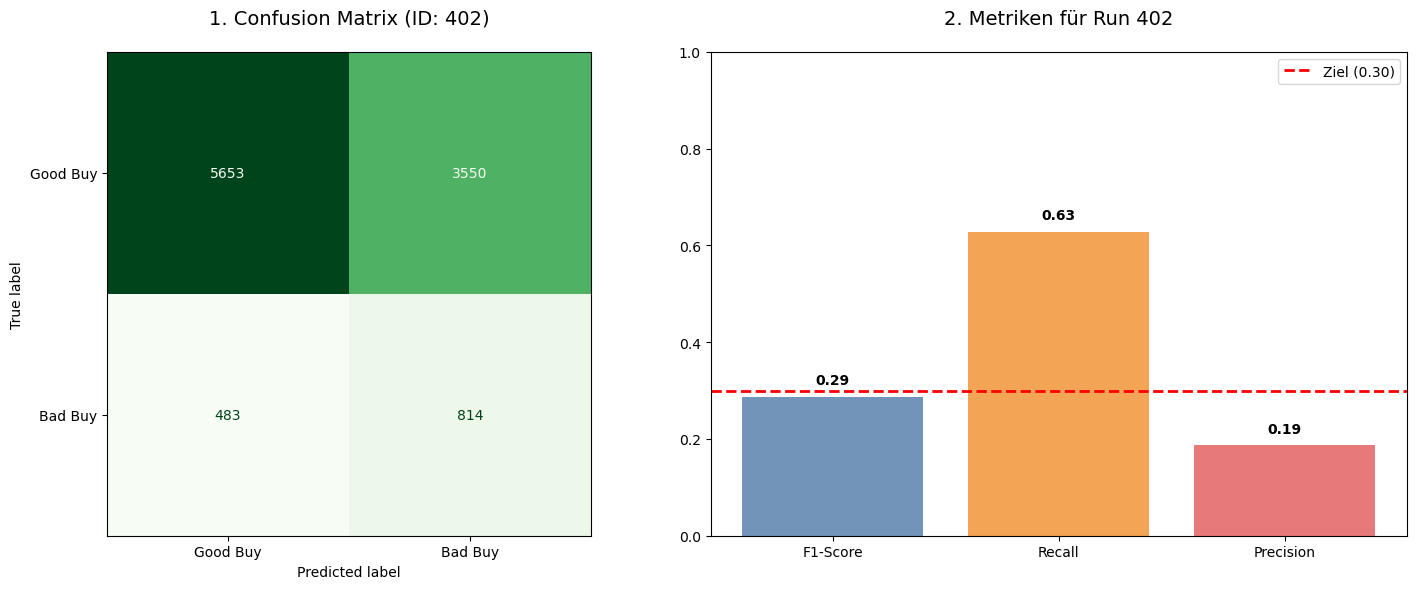

In [7]:
# BASE LINE PIPE


# --- 1. FEATURE SET (KORRIGIERT) ---
baseline_features = [
    'VehicleAge', 'VehOdo', 'VehBCost',
    'MMRAcquisitionAuctionAveragePrice',
    'feat_miles_per_year', 'feat_price_ratio',
    'Auction', 'Make'
]

# WICHTIG: Wir nutzen X_train (den 80% Split), nicht X_train_all!
X_train_baseline = X_train[baseline_features]

# --- 2. PIPELINE SETUP (KORRIGIERT) ---
# Wir nutzen X_train_baseline zur Typ-Prüfung
num_base = [f for f in baseline_features if X_train_baseline[f].dtype in ['int64', 'float64']]
cat_base = [f for f in baseline_features if X_train_baseline[f].dtype in ['category', 'object']]

pre_baseline = ColumnTransformer([
    ('num', StandardScaler(), num_base),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_base)
])

pipe_baseline = Pipeline([
    ('pre', pre_baseline),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])

# --- 3. TRAINING & PREDICTION ---
# Jetzt passen die Längen (41.996 vs 41.996) zusammen
pipe_baseline.fit(X_train_baseline, y_train)

# Validierung (nur auf den 20% Split)
y_pred_baseline = pipe_baseline.predict(X_val[baseline_features])

# --- 4. TRACKING & PLOTS ---
baseline_idx = tracker.add_entry(
    model_name="LogReg_BaseLine_Features",
    model_obj=pipe_baseline,
    features_name="baseline_features",
    features_list=baseline_features,
    y_true=y_val,
    y_pred=y_pred_baseline,
    description="Manuelle Baseline mit den 8 wichtigsten Features (Balanced)."
)

# --- 5. Model Tracker Results (KORRIGIERT) ---

# Wir holen uns die Ergebnisse und nutzen den Index 'baseline_idx'
results_df = tracker.get_results()
latest_res = results_df.iloc[baseline_idx] # <--- Hier lag der Fehler (vorher iloc[0])

print(f"📊 Visualisiere Run ID: {baseline_idx} | Modell: {latest_res['Model']}")
display(latest_res.to_frame().T) # Schöne horizontale Darstellung einer einzelnen Zeile


# --- 6. Plots (KORRIGIERT) ---

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(
    y_val, 
    y_pred_baseline, # <--- Sicherstellen, dass hier die aktuelle Vorhersage genutzt wird
    display_labels=["Good Buy", "Bad Buy"],
    cmap='Greens',
    ax=ax[0], 
    colorbar=False
)
ax[0].set_title(f"1. Confusion Matrix (ID: {baseline_idx})", fontsize=14, pad=20)

# --- PLOT 2: Bar Chart Metriken ---
# Wir nutzen die Werte aus 'latest_res', die wir gerade per Index geholt haben
metrics = ['F1-Score', 'Recall', 'Precision']
values = [latest_res['F1-Score'], latest_res['Recall'], latest_res['Precision']]

bars = ax[1].bar(metrics, values, color=['#4e79a7', '#f28e2b', '#e15759'], alpha=0.8)
ax[1].set_ylim(0, 1.0)
ax[1].set_title(f"2. Metriken für Run {baseline_idx}", fontsize=14, pad=20)

# Die magische 0.3-Linie
ax[1].axhline(y=0.3, color='red', linestyle='--', linewidth=2, label='Ziel (0.30)')
ax[1].legend(loc='upper right')

# Werte über die Balken schreiben
for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Der „Clean & Lean“ Baseline-Check

Unsere Baseline ist das wissenschaftliche Nullinstrument. Sie zeigt, was mit minimalem Aufwand (8 Features) und maximaler Transparenz möglich ist:

* **Strategie:** Fokus auf Signaldichte statt Datenmüll. Wir nutzen nur die 8 „Killer-Features“ (Alter, KM, Preis-Anomalien), um Multikollinearität und Rauschen zu vermeiden.
* **Recall (0,63) – Der Risikofilter:** Wir identifizieren bereits **63 % aller Problemfahrzeuge**. Das Modell agiert als Sicherheitsnetz, das fast zwei Drittel des Risikos abfängt.
* **Precision (0,19) – Die Baustelle:** Aktuell ist das Modell sehr „pessimistisch“. Von 100 Warnungen sind nur 19 echte Treffer. Hier liegt unser größtes Optimierungspotenzial für morgen.
* **F1-Score (0,29) – Die Startlinie:** Wir stehen unmittelbar vor der magischen **0,30-Grenze**. Dieser Wert ist unser Benchmark, den jedes komplexere Modell ab jetzt schlagen muss.

# Systematic Benchmarking

### Summary

#### Erster Durchlauf

##### Modelle
* **log_reg_balanced** (penalty='elasticnet', l1_ratio=0, solver='saga', class_weight='balanced')
* **log_reg_lasso** (penalty='elasticnet', l1_ratio=1, C=0.1, solver='saga', class_weight='balanced')
* **rf_shallow** (n_estimators=100, max_depth=7, class_weight='balanced')
* **rf_deep** (n_estimators=200, max_depth=15, min_samples_leaf=5, class_weight='balanced')
* **hist_boost_std** (max_iter=100, learning_rate=0.1, max_depth=5, class_weight='balanced')
* **hist_boost_aggressive** (max_iter=300, learning_rate=0.05, max_depth=10, l2_regularization=1.0, class_weight='balanced')
##### Pipe
* **ColorTransformer** mit **StandardScaler** und **OneHotEncoding**

#### Erkenntnisse
* Top Modelle **HistGradientBoosting** (Precision) und **LogisticRegression** (Recall)
* Beide performen mit **großen Feature-Sets** besser z.B. all_in_with_noise
* Tree-Modelle noch mal ohne OneHotEncoding ausprobieren


#### Vorauswahl
* SVM / Support Vector Machines: Zu rechenintensiv für ersten Run
* KNN / k-Nearest Neighbors: zu unprezise bei vielen Features
* XGBoost / LightGBM: ähnlich zu HistGradientBoosting
* Neuronale Netze: für den ersten Run zu komplexes Setup



In [14]:
import os
print(os.getcwd()) 
print(os.listdir('../data/04_models/')) 

/Users/kaywiegand/Workspace/DSC_Gebrauchtwagen/notebooks
['model_results_tracking-Mixed.csv', 'model_results_tracking.csv', '.ipynb_checkpoints', 'export']


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_results = pd.read_csv('../data/04_models/model_results_tracking-Mixed.csv') 

display(df_results.sort_values(['F1-Score','Recall'], ascending=False).head(33))

,Run_ID,Timestamp,Model,Features Name,Features Count,F1-Score,Recall,Precision,ROC-AUC,Description,Model_File,Is_Best
45,45,2026-04-01 08:53:50,hist_boost_all_in_with_noise,all_in_with_noise,28.0000,0.3726,0.6029,0.2696,0.0000,Auto-Run: hist_boost mit all_in_with_noise Fea...,export/045_hist_boost_all_in_with_noise.joblib,NaN
401,401,2026-04-01 11:02:30,log_reg_balanced_all_in_with_noise,NaN,NaN,0.3695,0.6130,0.2645,0.0000,Auto-Run: log_reg_balanced mit all_in_with_noi...,export/401_log_reg_balanced_all_in_with_noise....,False
43,43,2026-04-01 08:52:46,log_reg_all_in_with_noise,all_in_with_noise,28.0000,0.3676,0.6083,0.2634,0.0000,Auto-Run: log_reg mit all_in_with_noise Features,export/043_log_reg_all_in_with_noise.joblib,NaN
199,199,2026-04-01 09:22:36,hist_boost_std_cats_strong,NaN,NaN,0.3654,0.4557,0.3050,0.0000,Auto-Run: hist_boost_std mit cats_strong Features,export/199_hist_boost_std_cats_strong.joblib,False
284,284,2026-04-01 09:43:50,hist_boost_std_cats_strong,NaN,NaN,0.3654,0.4557,0.3050,0.0000,Auto-Run: hist_boost_std mit cats_strong Features,export/284_hist_boost_std_cats_strong.joblib,False
314,314,2026-04-01 09:48:13,hist_boost_std_high_impact_categories,NaN,NaN,0.3654,0.4557,0.3050,0.0000,Auto-Run: hist_boost_std mit high_impact_categ...,export/314_hist_boost_std_high_impact_categori...,False
363,363,2026-04-01 10:05:30,hist_boost_std_cats_strong,NaN,NaN,0.3654,0.4557,0.3050,0.0000,Auto-Run: hist_boost_std mit cats_strong Features,export/363_hist_boost_std_cats_strong.joblib,False
393,393,2026-04-01 10:09:34,hist_boost_std_high_impact_categories,NaN,NaN,0.3654,0.4557,0.3050,0.0000,Auto-Run: hist_boost_std mit high_impact_categ...,export/393_hist_boost_std_high_impact_categori...,False
200,200,2026-04-01 09:23:01,hist_boost_aggressive_cats_strong,NaN,NaN,0.3634,0.4827,0.2914,0.0000,Auto-Run: hist_boost_aggressive mit cats_stron...,export/200_hist_boost_aggressive_cats_strong.j...,False
285,285,2026-04-01 09:44:15,hist_boost_aggressive_cats_strong,NaN,NaN,0.3634,0.4827,0.2914,0.0000,Auto-Run: hist_boost_aggressive mit cats_stron...,export/285_hist_boost_aggressive_cats_strong.j...,False


### Run and Status

In [8]:
#SYSTEMATIC BENCHMARK


#----------------------------------------
# PIPELINE
#----------------------------------------
#----------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_pipeline(model_obj, feature_list, X_train):
    """
    Erstellt eine Scikit-Learn Pipeline basierend auf einer Feature-Liste.
    Trennt automatisch numerische und kategorische Spalten.
    """
    # 1. Spalten identifizieren, die TATSÄCHLICH in feature_list sind
    # (Verhindert Fehler, falls die Liste Spalten enthält, die nicht im DF sind)
    numeric_features = [col for col in feature_list if col in X_train.select_dtypes(include=['int64', 'float64']).columns]
    categorical_features = [col for col in feature_list if col in X_train.select_dtypes(include=['object', 'category']).columns]

    # 2. Transformer definieren
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # 3. ColumnTransformer zusammenbauen
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    # 4. Finale Pipeline mit dem übergebenen Modell-Objekt
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_obj)
    ])
    
#----------------------------------------
#----------------------------------------






#----------------------------------------
# LOOP
#----------------------------------------
#----------------------------------------

def start_loop(features_cat, model_cat):

    wg.print_header("STARTING SYSTEMATIC BENCHMARK")
    
    # Wir loopen durch alle Feature-Sets im Katalog
    for f_name, f_list in features_cat.items():
        
        wg.print_title(f"Testing Feature-Set: {f_name}")
        
        # Wir loopen durch alle Modelle im Katalog
        for m_name, m_obj in model_cat.items():
            
            run_name = f"{m_name}_{f_name}"
            
            # 1. Pipeline erstellen
            # Wichtig: Die Pipeline muss wissen, welche Spalten sie verarbeiten soll!
            pipeline = build_pipeline(m_obj, f_list, X_train) 
            
            # 2. Modell trainieren
            # Wir füttern nur die Spalten aus der aktuellen Liste
            pipeline.fit(X_train, y_train)
            
            # 3. Vorhersage auf dem Validation-Set
            y_val_pred = pipeline.predict(X_val)
            
            # 4. In den Tracker schreiben
            tracker.add_entry(
                model_name=run_name,
                model_obj=pipeline,
                features_name=f_name,
                features_list=f_list,
                y_true=y_val,
                y_pred=y_val_pred,
                description=f"Auto-Run: {m_name} mit {f_name} Features"
            )
    
    # 5. Speichern der CSV am Ende des gesamten Durchlaufs
    #tracker.save_to_csv()
    
    wg.print_header("BENCHMARK FINISHED")
    
#----------------------------------------
#----------------------------------------






#----------------------------------------
# CATALOGES
#----------------------------------------
#----------------------------------------

from config_features_catalog import features_catalog as features_catalog

    

from config_models_catalog import models_catalog as models_catalog


#----------------------------------------
#----------------------------------------




In [9]:
# ACTION

start_loop(features_catalog, models_catalog)

tracker.get_results().sort_values(by='F1-Score', ascending=False)




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
STARTING SYSTEMATIC BENCHMARK
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Testing Feature-Set: baseline
----------------------------------------


/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


ID 238: F1=0.2869 -> 🔈 Nur CSV (F1 zu niedrig)


/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


ID 239: F1=0.2855 -> 🔈 Nur CSV (F1 zu niedrig)
ID 240: F1=0.2906 -> 🔈 Nur CSV (F1 zu niedrig)
ID 241: F1=0.2882 -> 🔈 Nur CSV (F1 zu niedrig)
ID 242: F1=0.2933 -> 🔈 Nur CSV (F1 zu niedrig)
ID 243: F1=0.2895 -> 🔈 Nur CSV (F1 zu niedrig)

Testing Feature-Set: risk
----------------------------------------
ID 244: F1=0.2666 -> 🔈 Nur CSV (F1 zu niedrig)
ID 245: F1=0.2660 -> 🔈 Nur CSV (F1 zu niedrig)


...

/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


💾 Modell-Datei erstellt: ../data/04_models/export/322_log_reg_balanced_all_in_with_noise.joblib
ID 322: F1=0.3695 -> ✅ ÜBER 0.30 & GESPEICHERT


/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


💾 Modell-Datei erstellt: ../data/04_models/export/323_log_reg_lasso_all_in_with_noise.joblib
ID 323: F1=0.3801 -> 🏆 NEUER BESTWERT & GESPEICHERT
💾 Modell-Datei erstellt: ../data/04_models/export/324_rf_shallow_all_in_with_noise.joblib
ID 324: F1=0.3293 -> ✅ ÜBER 0.30 & GESPEICHERT
💾 Modell-Datei erstellt: ../data/04_models/export/325_rf_deep_all_in_with_noise.joblib
ID 325: F1=0.3610 -> ✅ ÜBER 0.30 & GESPEICHERT
💾 Modell-Datei erstellt: ../data/04_models/export/326_hist_boost_std_all_in_with_noise.joblib
ID 326: F1=0.3712 -> ✅ ÜBER 0.30 & GESPEICHERT
💾 Modell-Datei erstellt: ../data/04_models/export/327_hist_boost_aggressive_all_in_with_noise.joblib
ID 327: F1=0.3756 -> ✅ ÜBER 0.30 & GESPEICHERT



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
BENCHMARK FINISHED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


,Run_ID,Timestamp,Model,Features Name,Features Count,F1-Score,Recall,Precision,ROC-AUC,Description,Model_File,Is_Best
323,323,2026-04-01 10:55:38,log_reg_lasso_all_in_with_noise,NaN,NaN,0.3801,0.6245,0.2732,0.0000,Auto-Run: log_reg_lasso mit all_in_with_noise ...,export/323_log_reg_lasso_all_in_with_noise.joblib,True
327,327,2026-04-01 10:57:14,hist_boost_aggressive_all_in_with_noise,NaN,NaN,0.3756,0.6130,0.2708,0.0000,Auto-Run: hist_boost_aggressive mit all_in_wit...,export/327_hist_boost_aggressive_all_in_with_n...,False
45,45,2026-04-01 08:53:50,hist_boost_all_in_with_noise,all_in_with_noise,28.0000,0.3726,0.6029,0.2696,0.0000,Auto-Run: hist_boost mit all_in_with_noise Fea...,export/045_hist_boost_all_in_with_noise.joblib,NaN
326,326,2026-04-01 10:56:54,hist_boost_std_all_in_with_noise,NaN,NaN,0.3712,0.6045,0.2679,0.0000,Auto-Run: hist_boost_std mit all_in_with_noise...,export/326_hist_boost_std_all_in_with_noise.jo...,False
322,322,2026-04-01 10:40:54,log_reg_balanced_all_in_with_noise,NaN,NaN,0.3695,0.6130,0.2645,0.0000,Auto-Run: log_reg_balanced mit all_in_with_noi...,export/322_log_reg_balanced_all_in_with_noise....,False
...,...,...,...,...,...,...,...,...,...,...,...,...
205,205,2026-04-01 09:23:23,hist_boost_std_cats_weak,NaN,NaN,0.2252,0.4981,0.1455,0.0000,Auto-Run: hist_boost_std mit cats_weak Features,No,False
204,204,2026-04-01 09:23:22,rf_deep_cats_weak,NaN,NaN,0.2244,0.4510,0.1493,0.0000,Auto-Run: rf_deep mit cats_weak Features,No,False
289,289,2026-04-01 09:44:33,rf_deep_cats_weak,NaN,NaN,0.2244,0.4510,0.1493,0.0000,Auto-Run: rf_deep mit cats_weak Features,No,False
27,27,2026-04-01 08:49:58,hist_boost_cats_weak,cats_weak,6.0000,0.2240,0.4888,0.1453,0.0000,Auto-Run: hist_boost mit cats_weak Features,export/027_hist_boost_cats_weak.joblib,NaN
